# Passo 1 - Importar as libs

In [71]:
!pip install sklearn-som
!pip install pyclustertend

from sklearn.datasets import make_blobs
from pyclustertend import hopkins ## the hopkins test
from sklearn_som.som import SOM

# import aqui as libs necessárias
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import BatchNormalization

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Passo 2 - Carregar os dados

In [2]:
# considere o dataset (train.csv) Titanic disponível em https://www.kaggle.com/competitions/titanic/data?select=train.csv
data = pd.read_csv('./train.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Passo 3 - Trate os dados

In [4]:
# trate os dados faltantes. Escolha uma estratégia para preencher esses dados
# converta os tipos textuais em numéricos
# elimine variáveis indesejadas

data['Age'].fillna(data['Age'].mode()[0], inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

data = data.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1)

data['Sex'] = data['Sex'].astype('category').cat.codes
data['Embarked'] = data['Embarked'].astype('category').cat.codes

In [77]:
# separe o conjunto de dados em X e y, sendo o y a variável 'Survived'
# aplique a normalização MinMax no X

X = data.drop(['Survived'], axis=1)
y = data['Survived']

X_scaled = MinMaxScaler().fit_transform(X)

X_scaled.shape

(891, 7)

# Autoencoder

In [41]:
# split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

# scale data
t = MinMaxScaler()
t.fit(X_train)
X_train = t.transform(X_train)
X_test = t.transform(X_test)

In [43]:
print(X_train.shape)
print(X_test.shape)

(623, 7)
(268, 7)


In [66]:
n_inputs = X_scaled.shape[1]

# define encoder
visible = Input(shape=(n_inputs,))

# encoder level 1
e = Dense(n_inputs)(visible)
e = BatchNormalization()(e)
e = LeakyReLU()(e)

# encoder level 2
e = Dense(n_inputs*2)(e)
e = BatchNormalization()(e)
e = LeakyReLU()(e)

# encoder level 3
e = Dense(n_inputs)(visible)
e = BatchNormalization()(e)
e = LeakyReLU()(e)

# latent representation
n_components = 2
components = Dense(n_components)(e)

# define decoder, level 1
d = Dense(n_inputs)(components)
d = BatchNormalization()(d)
d = LeakyReLU()(d)

# decoder level 2
d = Dense(n_inputs*2)(d)
d = BatchNormalization()(d)
d = LeakyReLU()(d)

# decoder level final
d = Dense(n_inputs)(d)
d = BatchNormalization()(d)
d = LeakyReLU()(d)

# output layer
output = Dense(n_inputs, activation='linear')(d)

# define autoencoder model
model = Model(inputs=visible, outputs=output)
# compile autoencoder model
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, X_train, epochs=200, batch_size=16, verbose=2, validation_data=(X_test,X_test))

encoder = Model(inputs=visible, outputs=components)
encoder.compile(optimizer='adam', loss='mse')

Epoch 1/200
39/39 - 2s - loss: 0.6367 - val_loss: 0.2227 - 2s/epoch - 40ms/step
Epoch 2/200
39/39 - 0s - loss: 0.3687 - val_loss: 0.1793 - 117ms/epoch - 3ms/step
Epoch 3/200
39/39 - 0s - loss: 0.2438 - val_loss: 0.1415 - 112ms/epoch - 3ms/step
Epoch 4/200
39/39 - 0s - loss: 0.1716 - val_loss: 0.1105 - 102ms/epoch - 3ms/step
Epoch 5/200
39/39 - 0s - loss: 0.1256 - val_loss: 0.0875 - 90ms/epoch - 2ms/step
Epoch 6/200
39/39 - 0s - loss: 0.0976 - val_loss: 0.0722 - 99ms/epoch - 3ms/step
Epoch 7/200
39/39 - 0s - loss: 0.0764 - val_loss: 0.0609 - 100ms/epoch - 3ms/step
Epoch 8/200
39/39 - 0s - loss: 0.0620 - val_loss: 0.0521 - 108ms/epoch - 3ms/step
Epoch 9/200
39/39 - 0s - loss: 0.0536 - val_loss: 0.0484 - 97ms/epoch - 2ms/step
Epoch 10/200
39/39 - 0s - loss: 0.0508 - val_loss: 0.0454 - 103ms/epoch - 3ms/step
Epoch 11/200
39/39 - 0s - loss: 0.0465 - val_loss: 0.0424 - 112ms/epoch - 3ms/step
Epoch 12/200
39/39 - 0s - loss: 0.0445 - val_loss: 0.0405 - 100ms/epoch - 3ms/step
Epoch 13/200
39/39

# Avaliando

In [67]:
print(X_scaled.shape)
X_encoded = encoder.predict(X_scaled)

X_encoded.shape

(891, 7)


(891, 2)

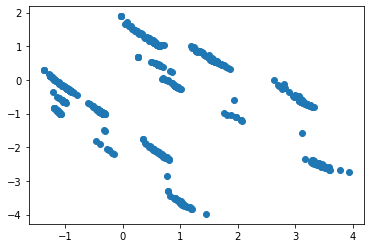

In [68]:
# plote a dispersão dos dados para esses 2 componentes
plt.scatter(X_encoded[:, 0], X_encoded[:, 1])

NMI
0.16837352432259636
0.20852778070156602
Dispersão encoded


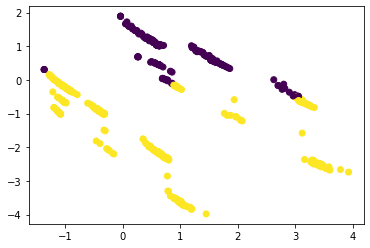

Dispersão y true


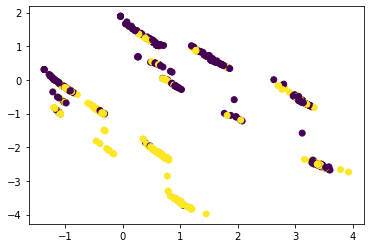

Hist encoded


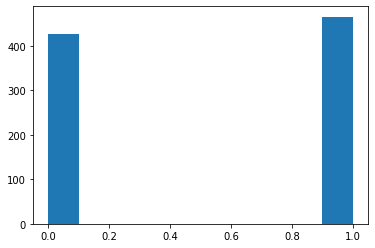

Hist sem encoded


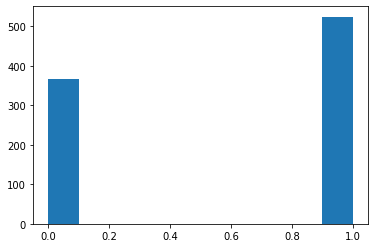

Hist y true


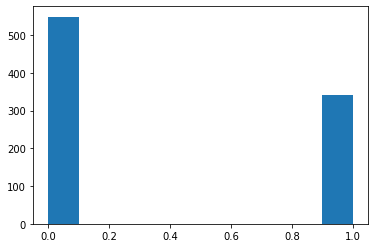

In [69]:
som = SOM(m=2, n=1, dim=2, random_state=0)
y_encoded_som = som.fit_predict(X_encoded)

som = SOM(m=2, n=1, dim=7, random_state=0)
y_scaled_som = som.fit_predict(X_scaled)

print('NMI')
print(normalized_mutual_info_score(y_encoded_som, y))
print(normalized_mutual_info_score(y_scaled_som, y))

print('Dispersão encoded')
_ = plt.scatter(X_encoded[:, 0], X_encoded[:, 1], c=y_encoded_som)
plt.show()

print('Dispersão y true')
_ = plt.scatter(X_encoded[:, 0], X_encoded[:, 1], c=y)
plt.show()

print('Hist encoded')
_ = plt.hist(y_encoded_som)
plt.show()

print('Hist sem encoded')
_ = plt.hist(y_scaled_som)
plt.show()

print('Hist y true')
_ = plt.hist(y)

0.011350738992690684

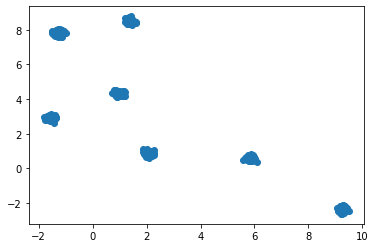

In [84]:
X_new, y_new = make_blobs(
    n_samples=500, centers=7, n_features=2, random_state=0, cluster_std=0.1
)

plt.scatter(X_new[:, 0], X_new[:, 1])

hopkins(X_new, X_new.shape[0])

0.018752646832453746

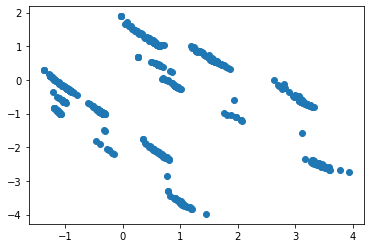

In [85]:
plt.scatter(X_encoded[:, 0], X_encoded[:, 1])

hopkins(X_encoded, X_encoded.shape[0])